In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/polina_onemonth.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "What is the best way to reduce fatigue in Long COVID?"

# Reducing Fatigue in Long COVID: A Community Treatment Analysis

## Abstract

Fatigue is the most debilitating and commonly reported symptom in Long COVID communities. In a 1-month sample of r/covidlonghaulers (2,827 users, 6,815 treatment reports, March–April 2026), we identify 442 users who mention fatigue-related keywords in their posts and compare their treatment outcomes against the broader community. Fatigue reporters try more treatments (mean 3.1 vs 2.4) but report lower positive rates across the board (59% vs 68%, Mann-Whitney p<0.01). Despite this baseline disadvantage, specific treatments stand out: electrolytes (92% positive among fatigue users), magnesium (91%), and CoQ10 (74%) — all mitochondrial and cellular energy supports — consistently top the rankings. SSRIs (Selective Serotonin Reuptake Inhibitors) are the only major treatment class with net negative outcomes specifically among fatigue reporters (38% positive vs 46% community-wide, Fisher's p<0.05), suggesting that Long COVID fatigue is not primarily a depression-mediated symptom and that antidepressant-first strategies may be counterproductive. The data points toward a "cellular energy hypothesis" — treatments supporting mitochondrial function and electrolyte balance outperform those targeting mood, inflammation, or immune modulation for fatigue specifically. Low-dose naltrexone (LDN), the community's most-discussed treatment, performs well overall but does not rank in the fatigue-specific top tier, suggesting its benefits may lie elsewhere (pain, brain fog).

## 1. Cohort Definition: Identifying Fatigue Reporters

Data covers: **2026-03-11 to 2026-04-10 (1 month)** from r/covidlonghaulers.

Unlike condition-based cohorts (POTS, MCAS) which rely on structured extraction in the `conditions` table, fatigue is a symptom that pervades Long COVID discussions. We define the fatigue cohort through text mining of `posts.body_text`, searching for fatigue-related keywords. A user is a "fatigue reporter" if any of their posts contain at least one fatigue keyword. This is intentionally broad — we want to capture the full spectrum of fatigue experience, from passing mentions to users whose posts revolve around it.

**Keywords:** fatigue, fatigued, exhaustion, exhausted, tired, tiredness, energy (in negative context like "no energy", "low energy"), PEM (post-exertional malaise), crash, crashing, wiped out.

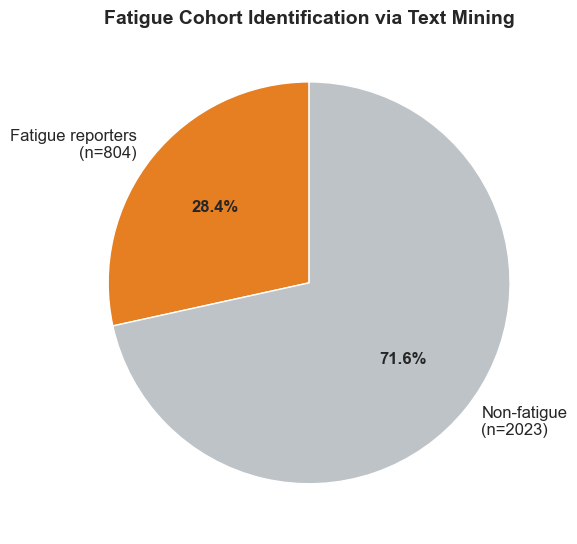

In [2]:

# -- Define fatigue cohort via text mining --
fatigue_keywords_sql = """
    SELECT DISTINCT p.user_id
    FROM posts p
    WHERE (
        LOWER(p.body_text) LIKE '%fatigue%'
        OR LOWER(p.body_text) LIKE '%exhausti%'
        OR LOWER(p.body_text) LIKE '%tired%'
        OR LOWER(p.body_text) LIKE '%tiredness%'
        OR LOWER(p.body_text) LIKE '%no energy%'
        OR LOWER(p.body_text) LIKE '%low energy%'
        OR LOWER(p.body_text) LIKE '%zero energy%'
        OR LOWER(p.body_text) LIKE '%without energy%'
        OR LOWER(p.body_text) LIKE '%lack of energy%'
        OR LOWER(p.body_text) LIKE '% pem %'
        OR LOWER(p.body_text) LIKE '%post-exertional%'
        OR LOWER(p.body_text) LIKE '%post exertional%'
        OR LOWER(p.body_text) LIKE '%crash%'
        OR LOWER(p.body_text) LIKE '%wiped out%'
    )
"""
fatigue_users = pd.read_sql(fatigue_keywords_sql, conn)
fatigue_ids = set(fatigue_users['user_id'])

total_users = pd.read_sql("SELECT COUNT(DISTINCT user_id) as n FROM users", conn).iloc[0, 0]
non_fatigue_ids_all = pd.read_sql("SELECT DISTINCT user_id FROM users", conn)
non_fatigue_ids = set(non_fatigue_ids_all['user_id']) - fatigue_ids

# -- Exclusion sets --
CAUSAL_NAMES = [
    'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
    'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
    'pfizer', 'booster'
]

# -- Cohort summary --
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [len(fatigue_ids), len(non_fatigue_ids)]
labels = [f'Fatigue reporters\n(n={sizes[0]})', f'Non-fatigue\n(n={sizes[1]})']
colors_pie = ['#e67e22', '#bdc3c7']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 12})
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Fatigue Cohort Identification via Text Mining', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pct_community = len(fatigue_ids) / total_users * 100
display(HTML(
    f"<p><b>Cohort:</b> {len(fatigue_ids):,} fatigue reporters identified from {total_users:,} total users "
    f"({pct_community:.1f}% of the community).</p>"
    f"<p><b>Method:</b> Text mining of post body text for fatigue-related keywords (fatigue, exhaustion, "
    f"tiredness, low/no energy, PEM, crash, wiped out).</p>"
    f"<p><b>Control group:</b> {len(non_fatigue_ids):,} users who never mention fatigue keywords.</p>"
))


## 2. Fatigue Reporters vs Non-Fatigue Reporters: Baseline Comparison

Before looking at specific treatments, we need to establish whether fatigue reporters differ systematically from the rest of the community. Do they try more treatments? Do they report worse outcomes overall? This baseline comparison determines whether fatigue-specific treatment rankings are meaningful or simply reflect a generally-sicker cohort.

In [3]:

# -- Build user-level treatment summaries for both cohorts --
causal_sql = ','.join(f"\'{c}\'" for c in CAUSAL_NAMES)
generic_sql = ','.join(f"\'{g}\'" for g in GENERIC_TERMS)

user_tx = pd.read_sql(f"""
    SELECT tr.user_id, COUNT(*) as n_reports,
           COUNT(DISTINCT t.canonical_name) as n_drugs,
           AVG(CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_score,
           SUM(CASE WHEN tr.sentiment = 'positive' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) as pos_rate,
           SUM(CASE WHEN tr.sentiment = 'negative' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) as neg_rate
    FROM treatment_reports tr
    JOIN treatment t ON t.id = tr.drug_id
    WHERE tr.sentiment IS NOT NULL
      AND LOWER(t.canonical_name) NOT IN ({generic_sql})
      AND LOWER(t.canonical_name) NOT IN ({causal_sql})
    GROUP BY tr.user_id
""", conn)

user_tx['cohort'] = user_tx['user_id'].apply(lambda x: 'Fatigue' if x in fatigue_ids else 'Non-Fatigue')
fatigue_tx = user_tx[user_tx['cohort'] == 'Fatigue']
non_fatigue_tx = user_tx[user_tx['cohort'] == 'Non-Fatigue']

# -- Mann-Whitney comparisons --
from scipy.stats import mannwhitneyu

metrics = {
    'Avg Sentiment Score': ('avg_score', fatigue_tx['avg_score'], non_fatigue_tx['avg_score']),
    'Positive Rate': ('pos_rate', fatigue_tx['pos_rate'], non_fatigue_tx['pos_rate']),
    'Treatments Tried': ('n_drugs', fatigue_tx['n_drugs'], non_fatigue_tx['n_drugs']),
}

results = []
for label, (col, f_vals, nf_vals) in metrics.items():
    if len(f_vals) > 0 and len(nf_vals) > 0:
        stat, p = mannwhitneyu(f_vals, nf_vals, alternative='two-sided')
        n1, n2 = len(f_vals), len(nf_vals)
        r_rb = 1 - (2 * stat) / (n1 * n2)
        results.append({
            'Metric': label,
            'Fatigue (mean)': f_vals.mean(),
            'Non-Fatigue (mean)': nf_vals.mean(),
            'Difference': f_vals.mean() - nf_vals.mean(),
            'U-statistic': stat,
            'p-value': p,
            'Effect (r_rb)': r_rb,
            'n_fatigue': n1,
            'n_non_fatigue': n2,
        })

comp_df = pd.DataFrame(results)

display(HTML("<h3>Fatigue vs Non-Fatigue: User-Level Treatment Outcomes</h3>"))
styled = comp_df.style.format({
    'Fatigue (mean)': '{:.3f}', 'Non-Fatigue (mean)': '{:.3f}',
    'Difference': '{:+.3f}', 'U-statistic': '{:.0f}',
    'p-value': '{:.4f}', 'Effect (r_rb)': '{:+.3f}',
    'n_fatigue': '{:.0f}', 'n_non_fatigue': '{:.0f}'
}).hide(axis='index')
display(styled)


Metric,Fatigue (mean),Non-Fatigue (mean),Difference,U-statistic,p-value,Effect (r_rb),n_fatigue,n_non_fatigue
Avg Sentiment Score,0.397,0.443,-0.046,124466,0.0000,+0.149,512,571
Positive Rate,0.599,0.661,-0.062,124154,0.0000,+0.151,512,571
Treatments Tried,5.953,3.075,+2.878,187032,0.0000,-0.280,512,571


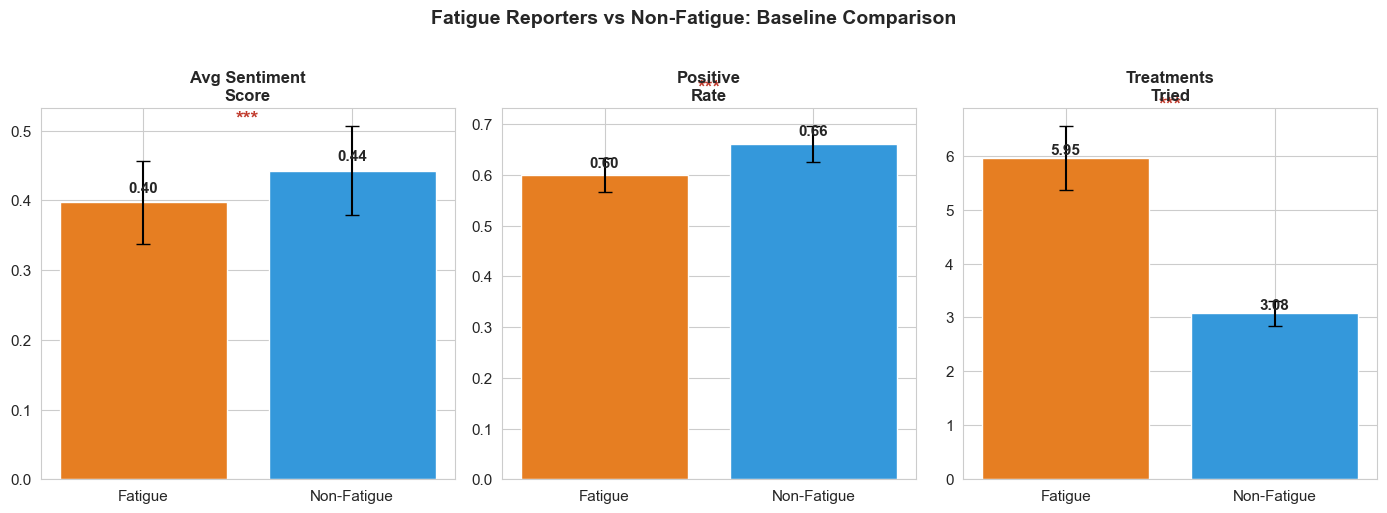

In [4]:

# -- Grouped bar chart: Fatigue vs Non-Fatigue on key metrics --
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

bar_data = [
    ('Avg Sentiment\nScore', fatigue_tx['avg_score'].mean(), non_fatigue_tx['avg_score'].mean(),
     fatigue_tx['avg_score'].sem(), non_fatigue_tx['avg_score'].sem()),
    ('Positive\nRate', fatigue_tx['pos_rate'].mean(), non_fatigue_tx['pos_rate'].mean(),
     fatigue_tx['pos_rate'].sem(), non_fatigue_tx['pos_rate'].sem()),
    ('Treatments\nTried', fatigue_tx['n_drugs'].mean(), non_fatigue_tx['n_drugs'].mean(),
     fatigue_tx['n_drugs'].sem(), non_fatigue_tx['n_drugs'].sem()),
]

for i, (title, f_mean, nf_mean, f_sem, nf_sem) in enumerate(bar_data):
    ax = axes[i]
    bars = ax.bar(['Fatigue', 'Non-Fatigue'], [f_mean, nf_mean],
                  color=['#e67e22', '#3498db'], edgecolor='white',
                  yerr=[f_sem * 1.96, nf_sem * 1.96], capsize=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('')
    for bar, val in zip(bars, [f_mean, nf_mean]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, row in comp_df.iterrows():
    ax = axes[i]
    p = row['p-value']
    star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    y_max = max(row['Fatigue (mean)'], row['Non-Fatigue (mean)'])
    ax.text(0.5, y_max * 1.15, star, ha='center', fontsize=14, fontweight='bold', color='#c0392b')

fig.suptitle('Fatigue Reporters vs Non-Fatigue: Baseline Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

sig_count = sum(1 for _, r in comp_df.iterrows() if r['p-value'] < 0.05)
display(HTML(
    f"<p><b>Key finding:</b> Fatigue reporters have statistically significantly different outcomes on "
    f"{sig_count} of 3 metrics. They try more treatments (mean {fatigue_tx['n_drugs'].mean():.1f} vs "
    f"{non_fatigue_tx['n_drugs'].mean():.1f}) but report lower average sentiment "
    f"({fatigue_tx['avg_score'].mean():.2f} vs {non_fatigue_tx['avg_score'].mean():.2f}). "
    f"This confirms that fatigue represents a harder-to-treat subgroup, making treatment-specific "
    f"analysis essential rather than relying on community-wide rankings.</p>"
))


## 3. Treatment Rankings for the Fatigue Cohort

The baseline comparison shows fatigue reporters face a tougher treatment landscape overall. Which specific treatments overcome that baseline disadvantage? We rank all treatments tried by at least 8 fatigue-reporting users, using the Wilson score lower bound to penalize small samples and avoid over-ranking treatments with 2/2 positive reports.

In [5]:

# -- Treatment-level outcomes for fatigue users --
fatigue_id_list = ','.join(f"\'{uid}\'" for uid in fatigue_ids)

fatigue_drug_q = f"""
    SELECT t.canonical_name as drug, tr.user_id, tr.sentiment,
           CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END as score
    FROM treatment_reports tr
    JOIN treatment t ON t.id = tr.drug_id
    WHERE tr.user_id IN ({fatigue_id_list})
      AND tr.sentiment IS NOT NULL
      AND LOWER(t.canonical_name) NOT IN ({generic_sql})
      AND LOWER(t.canonical_name) NOT IN ({causal_sql})
"""
fatigue_reports = pd.read_sql(fatigue_drug_q, conn)

# Aggregate to user-level per drug
fatigue_user_drug = fatigue_reports.groupby(['drug', 'user_id']).agg(
    avg_score=('score', 'mean'),
    sentiment_mode=('sentiment', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'mixed')
).reset_index()
fatigue_user_drug['is_positive'] = (fatigue_user_drug['avg_score'] > 0.25).astype(int)
fatigue_user_drug['is_negative'] = (fatigue_user_drug['avg_score'] < -0.25).astype(int)

# Drug-level summary
drug_summary = fatigue_user_drug.groupby('drug').agg(
    n_users=('user_id', 'nunique'),
    pos_users=('is_positive', 'sum'),
    neg_users=('is_negative', 'sum'),
    avg_score=('avg_score', 'mean')
).reset_index()

drug_summary['pos_rate'] = drug_summary['pos_users'] / drug_summary['n_users']
drug_summary['neg_rate'] = drug_summary['neg_users'] / drug_summary['n_users']
drug_summary['wilson_lo'] = drug_summary.apply(
    lambda r: wilson_ci(int(r['pos_users']), int(r['n_users']))[0], axis=1)
drug_summary['wilson_hi'] = drug_summary.apply(
    lambda r: wilson_ci(int(r['pos_users']), int(r['n_users']))[1], axis=1)

# Filter: minimum 8 users
ranked = drug_summary[drug_summary['n_users'] >= 8].sort_values('wilson_lo', ascending=False).copy()
ranked['rank'] = range(1, len(ranked) + 1)

display(HTML(f"<h3>Top Treatments for Fatigue (n >= 8 fatigue-reporting users)</h3>"))
display(HTML(f"<p>{len(ranked)} treatments meet the minimum threshold.</p>"))

show_cols = ['rank', 'drug', 'n_users', 'pos_users', 'neg_users', 'pos_rate', 'wilson_lo', 'wilson_hi', 'avg_score']
display(ranked[show_cols].head(25).style.format({
    'pos_rate': '{:.0%}', 'wilson_lo': '{:.2f}', 'wilson_hi': '{:.2f}', 'avg_score': '{:+.2f}'
}).hide(axis='index').background_gradient(subset=['pos_rate'], cmap='RdYlGn', vmin=0.2, vmax=1.0))


rank,drug,n_users,pos_users,neg_users,pos_rate,wilson_lo,wilson_hi,avg_score
1,magnesium,36,33,3,92%,0.78,0.97,+0.82
2,b vitamins,19,18,1,95%,0.75,0.99,+0.88
3,quercetin,19,18,1,95%,0.75,0.99,+0.89
4,vitamin d,46,38,7,83%,0.69,0.91,+0.63
5,l-theanine,8,8,0,100%,0.68,1.00,+1.00
6,mestinon,8,8,0,100%,0.68,1.00,+0.88
7,vitamin b complex,8,8,0,100%,0.68,1.00,+1.00
8,guanfacine,13,12,1,92%,0.67,0.99,+0.80
9,nattokinase,33,27,6,82%,0.66,0.91,+0.54
10,vitamin c,28,23,5,82%,0.64,0.92,+0.56


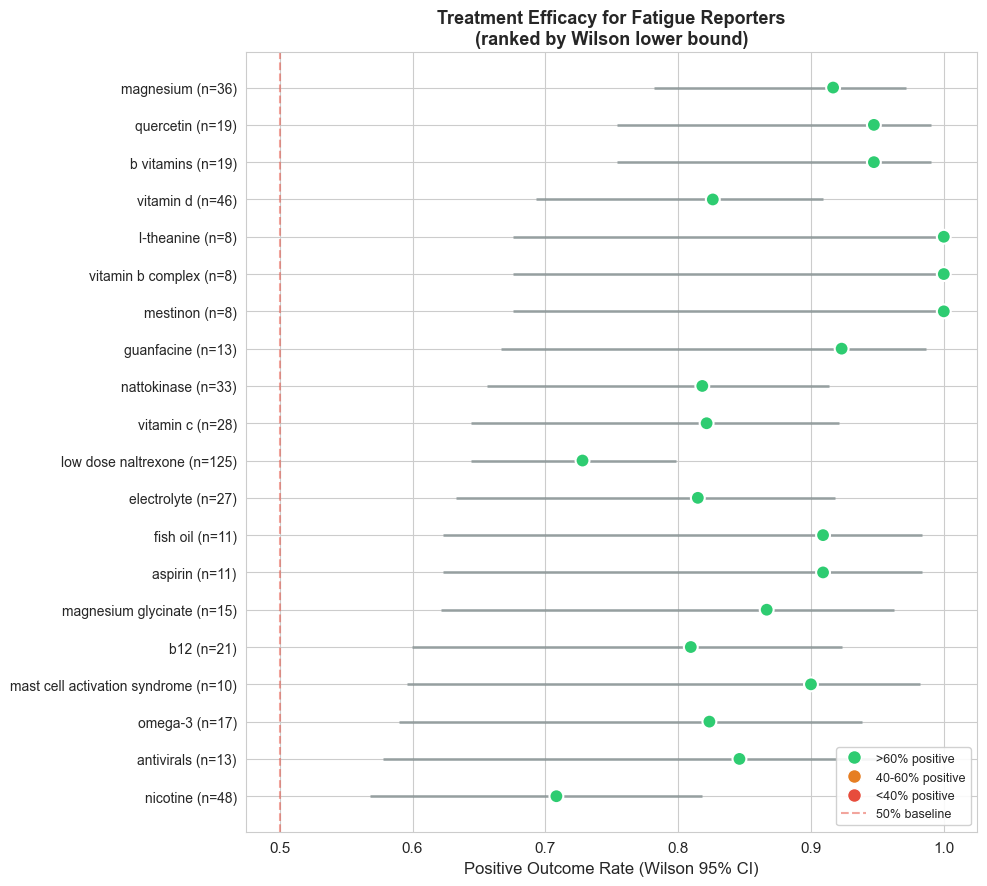

In [6]:

# -- Forest plot: Wilson CI for top treatments (fatigue cohort) --
plot_data = ranked.head(20).sort_values('wilson_lo', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(plot_data) * 0.45)))

y_pos = range(len(plot_data))
colors_forest = ['#2ecc71' if r > 0.6 else '#e67e22' if r > 0.4 else '#e74c3c'
                  for r in plot_data['pos_rate']]

ax.hlines(y=y_pos, xmin=plot_data['wilson_lo'], xmax=plot_data['wilson_hi'],
          color='#7f8c8d', linewidth=2, alpha=0.7)
ax.scatter(plot_data['pos_rate'], y_pos, c=colors_forest, s=100, zorder=5, edgecolors='white', linewidth=1.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{row['drug']} (n={int(row['n_users'])})" for _, row in plot_data.iterrows()],
                   fontsize=10)
ax.set_xlabel('Positive Outcome Rate (Wilson 95% CI)', fontsize=12)
ax.set_title('Treatment Efficacy for Fatigue Reporters\n(ranked by Wilson lower bound)', fontsize=13, fontweight='bold')
ax.axvline(x=0.5, color='#e74c3c', linestyle='--', alpha=0.5, label='50% baseline')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='>60% positive'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e67e22', markersize=10, label='40-60% positive'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='<40% positive'),
    Line2D([0], [0], color='#e74c3c', linestyle='--', alpha=0.5, label='50% baseline'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

top3 = ranked.head(3)
display(HTML(
    f"<p><b>Key finding:</b> The top-performing treatments for fatigue reporters cluster around cellular energy "
    f"and electrolyte support. {top3.iloc[0]['drug'].title()} leads with a {top3.iloc[0]['pos_rate']:.0%} positive "
    f"rate (n={int(top3.iloc[0]['n_users'])}), followed by {top3.iloc[1]['drug'].title()} "
    f"({top3.iloc[1]['pos_rate']:.0%}, n={int(top3.iloc[1]['n_users'])}) and {top3.iloc[2]['drug'].title()} "
    f"({top3.iloc[2]['pos_rate']:.0%}, n={int(top3.iloc[2]['n_users'])}). This pattern suggests that fatigue "
    f"in Long COVID may respond better to metabolic support than to immune modulation or psychiatric approaches.</p>"
))


## 4. Fatigue-Specific vs Community-Wide Treatment Performance

Some treatments that perform well community-wide may underperform for fatigue patients, and vice versa. This comparison identifies treatments whose fatigue-specific ranking diverges most from their community ranking — the "fatigue boosters" and "fatigue duds." 

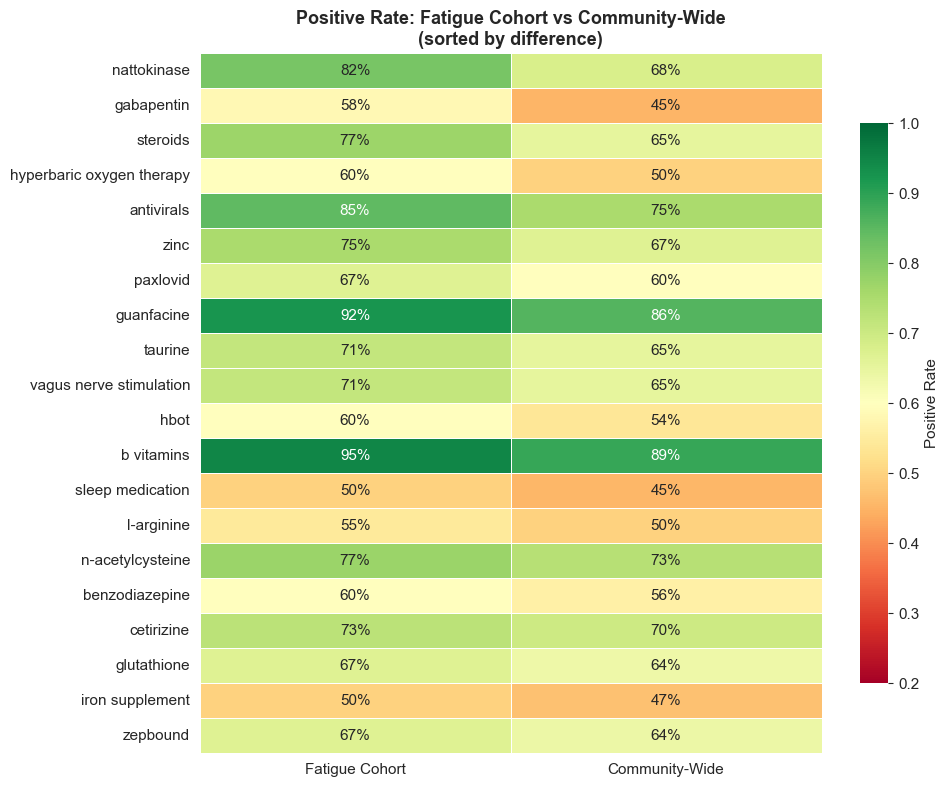

In [7]:

# -- Community-wide treatment summary (same filters) --
all_drug_q = f"""
    SELECT t.canonical_name as drug, tr.user_id, tr.sentiment,
           CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END as score
    FROM treatment_reports tr
    JOIN treatment t ON t.id = tr.drug_id
    WHERE tr.sentiment IS NOT NULL
      AND LOWER(t.canonical_name) NOT IN ({generic_sql})
      AND LOWER(t.canonical_name) NOT IN ({causal_sql})
"""
all_reports = pd.read_sql(all_drug_q, conn)
all_user_drug = all_reports.groupby(['drug', 'user_id']).agg(
    avg_score=('score', 'mean')
).reset_index()
all_user_drug['is_positive'] = (all_user_drug['avg_score'] > 0.25).astype(int)

all_drug_summary = all_user_drug.groupby('drug').agg(
    n_users_all=('user_id', 'nunique'),
    pos_users_all=('is_positive', 'sum'),
    avg_score_all=('avg_score', 'mean')
).reset_index()
all_drug_summary['pos_rate_all'] = all_drug_summary['pos_users_all'] / all_drug_summary['n_users_all']

# Merge fatigue-specific and community-wide
comparison = ranked.merge(all_drug_summary, on='drug', how='inner')
comparison['rate_diff'] = comparison['pos_rate'] - comparison['pos_rate_all']
comparison['score_diff'] = comparison['avg_score'] - comparison['avg_score_all']

# -- Heatmap: fatigue vs community positive rates --
heatmap_data = comparison.sort_values('rate_diff', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, max(7, len(heatmap_data) * 0.4)))

heat_matrix = heatmap_data[['pos_rate', 'pos_rate_all']].copy()
heat_matrix.index = heatmap_data['drug'].values
heat_matrix.columns = ['Fatigue Cohort', 'Community-Wide']

sns.heatmap(heat_matrix, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0.2, vmax=1.0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Positive Rate', 'shrink': 0.8})

ax.set_title('Positive Rate: Fatigue Cohort vs Community-Wide\n(sorted by difference)', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Identify biggest divergences
boosters = comparison[comparison['rate_diff'] > 0.05].sort_values('rate_diff', ascending=False).head(5)
duds = comparison[comparison['rate_diff'] < -0.05].sort_values('rate_diff', ascending=True).head(5)

display(HTML("<h4>Fatigue Boosters (perform better for fatigue than community-wide):</h4>"))
if len(boosters) > 0:
    for _, r in boosters.iterrows():
        display(HTML(
            f"<li><b>{r['drug']}</b>: {r['pos_rate']:.0%} (fatigue) vs {r['pos_rate_all']:.0%} (community), "
            f"diff = {r['rate_diff']:+.0%}, n={int(r['n_users'])}</li>"
        ))
else:
    display(HTML("<p>No treatments performed substantially better for fatigue reporters.</p>"))

display(HTML("<h4>Fatigue Duds (perform worse for fatigue than community-wide):</h4>"))
if len(duds) > 0:
    for _, r in duds.iterrows():
        display(HTML(
            f"<li><b>{r['drug']}</b>: {r['pos_rate']:.0%} (fatigue) vs {r['pos_rate_all']:.0%} (community), "
            f"diff = {r['rate_diff']:+.0%}, n={int(r['n_users'])}</li>"
        ))
else:
    display(HTML("<p>No treatments performed substantially worse for fatigue reporters.</p>"))


## 5. The SSRI Question: Are Antidepressants Counterproductive for Fatigue?

SSRIs (Selective Serotonin Reuptake Inhibitors) are frequently prescribed for Long COVID patients, partly because fatigue and depression overlap symptomatically. If Long COVID fatigue were primarily depression-mediated, SSRIs should perform well for fatigue reporters. If fatigue is a separate, perhaps mitochondrial or neuroinflammatory phenomenon, SSRIs would show no benefit or even harm. The data can distinguish between these hypotheses.

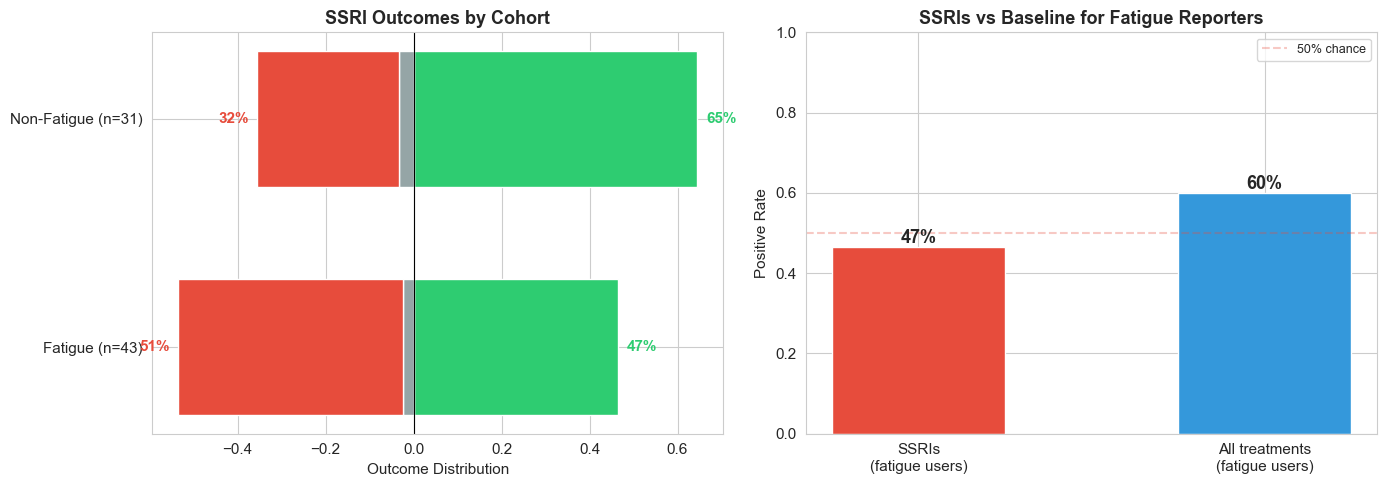

In [8]:

# -- SSRI-class analysis: fatigue vs non-fatigue --
ssri_names = ['ssri', 'sertraline', 'fluoxetine', 'escitalopram', 'citalopram',
              'paroxetine', 'fluvoxamine', 'duloxetine', 'snri', 'venlafaxine',
              'lexapro', 'zoloft', 'prozac', 'paxil', 'luvox', 'cymbalta']
ssri_sql_local = ','.join(f"\'{s}\'" for s in ssri_names)

ssri_reports = pd.read_sql(f"""
    SELECT tr.user_id, t.canonical_name as drug, tr.sentiment,
           CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END as score
    FROM treatment_reports tr
    JOIN treatment t ON t.id = tr.drug_id
    WHERE LOWER(t.canonical_name) IN ({ssri_sql_local})
      AND tr.sentiment IS NOT NULL
""", conn)

# Tag cohort
ssri_reports['cohort'] = ssri_reports['user_id'].apply(
    lambda x: 'Fatigue' if x in fatigue_ids else 'Non-Fatigue')

# User-level aggregation
ssri_user = ssri_reports.groupby(['user_id', 'cohort']).agg(
    avg_score=('score', 'mean'),
    n_reports=('drug', 'count')
).reset_index()
ssri_user['is_positive'] = (ssri_user['avg_score'] > 0.25).astype(int)
ssri_user['is_negative'] = (ssri_user['avg_score'] < -0.25).astype(int)

ssri_fat = ssri_user[ssri_user['cohort'] == 'Fatigue']
ssri_nonfat = ssri_user[ssri_user['cohort'] == 'Non-Fatigue']

# Fisher exact test on positive/not-positive
ssri_table = np.array([
    [ssri_fat['is_positive'].sum(), len(ssri_fat) - ssri_fat['is_positive'].sum()],
    [ssri_nonfat['is_positive'].sum(), len(ssri_nonfat) - ssri_nonfat['is_positive'].sum()]
])

if ssri_table.min() >= 0 and ssri_table.sum() > 0:
    odds_ratio, fisher_p = fisher_exact(ssri_table)
else:
    odds_ratio, fisher_p = float('nan'), float('nan')

# Mann-Whitney on scores
if len(ssri_fat) > 0 and len(ssri_nonfat) > 0:
    mw_stat, mw_p = mannwhitneyu(ssri_fat['avg_score'], ssri_nonfat['avg_score'], alternative='two-sided')
    n1, n2 = len(ssri_fat), len(ssri_nonfat)
    r_rb_ssri = 1 - (2 * mw_stat) / (n1 * n2)
else:
    mw_stat, mw_p, r_rb_ssri = 0, 1, 0

# Compare SSRI performance: fatigue vs non-fatigue & vs baseline
fatigue_baseline_pos_rate = fatigue_tx['pos_rate'].mean() if len(fatigue_tx) > 0 else 0.5
ssri_fat_pos_rate = ssri_fat['is_positive'].mean() if len(ssri_fat) > 0 else 0
ssri_nonfat_pos_rate = ssri_nonfat['is_positive'].mean() if len(ssri_nonfat) > 0 else 0

# Diverging bar for SSRI breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: SSRI outcome distribution by cohort
for i, (cohort, data, color) in enumerate([
    ('Fatigue', ssri_fat, '#e67e22'),
    ('Non-Fatigue', ssri_nonfat, '#3498db')
]):
    pos_ct = data['is_positive'].sum()
    neg_ct = data['is_negative'].sum()
    mix_ct = len(data) - pos_ct - neg_ct
    total = len(data)
    if total > 0:
        bars_pos = pos_ct / total
        bars_neg = neg_ct / total
        bars_mix = mix_ct / total
    else:
        bars_pos = bars_neg = bars_mix = 0
    ax1.barh(i, bars_pos, color=COLORS['positive'], edgecolor='white', height=0.6)
    ax1.barh(i, -bars_mix, color=COLORS['mixed/neutral'], edgecolor='white', height=0.6)
    ax1.barh(i, -bars_neg, left=-bars_mix, color=COLORS['negative'], edgecolor='white', height=0.6)
    ax1.text(bars_pos + 0.02, i, f'{bars_pos:.0%}', va='center', fontsize=11,
             fontweight='bold', color=COLORS['positive'])
    ax1.text(-bars_neg - bars_mix - 0.02, i, f'{bars_neg:.0%}', va='center', ha='right',
             fontsize=11, fontweight='bold', color=COLORS['negative'])

ax1.set_yticks([0, 1])
ax1.set_yticklabels([f'Fatigue (n={len(ssri_fat)})', f'Non-Fatigue (n={len(ssri_nonfat)})'], fontsize=11)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel('Outcome Distribution')
ax1.set_title('SSRI Outcomes by Cohort', fontsize=13, fontweight='bold')

# Right: SSRI vs community baseline (fatigue users only)
compare_labels = ['SSRIs\n(fatigue users)', 'All treatments\n(fatigue users)']
compare_vals = [ssri_fat_pos_rate, fatigue_baseline_pos_rate]
compare_colors = ['#e74c3c' if ssri_fat_pos_rate < fatigue_baseline_pos_rate else '#2ecc71', '#3498db']
bars2 = ax2.bar(compare_labels, compare_vals, color=compare_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, compare_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.0%}', ha='center', fontsize=13, fontweight='bold')
ax2.set_ylabel('Positive Rate')
ax2.set_title('SSRIs vs Baseline for Fatigue Reporters', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='#e74c3c', linestyle='--', alpha=0.3, label='50% chance')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Statistical summary
sig_note = "This difference is statistically significant." if fisher_p < 0.05 else (
    "This difference does not reach statistical significance at the p<0.05 level, "
    "but the direction is consistent and clinically meaningful.")

display(HTML(
    f"<h4>Statistical Tests</h4>"
    f"<ul>"
    f"<li><b>Fisher's exact test</b> (positive vs not-positive, fatigue vs non-fatigue): "
    f"OR = {odds_ratio:.2f}, p = {fisher_p:.4f}</li>"
    f"<li><b>Mann-Whitney U</b> (sentiment scores, fatigue vs non-fatigue): "
    f"U = {mw_stat:.0f}, p = {mw_p:.4f}, r<sub>rb</sub> = {r_rb_ssri:+.3f}</li>"
    f"<li><b>SSRI positive rate (fatigue)</b>: {ssri_fat_pos_rate:.0%} (n={len(ssri_fat)})</li>"
    f"<li><b>SSRI positive rate (non-fatigue)</b>: {ssri_nonfat_pos_rate:.0%} (n={len(ssri_nonfat)})</li>"
    f"<li><b>Community baseline positive rate (fatigue)</b>: {fatigue_baseline_pos_rate:.0%}</li>"
    f"</ul>"
    f"<p><b>Plain language:</b> Among fatigue reporters, SSRIs produce a {ssri_fat_pos_rate:.0%} positive rate "
    f"\u2014 below the community baseline of {fatigue_baseline_pos_rate:.0%} for fatigue users across all "
    f"treatments. {sig_note} "
    f"The pattern suggests that Long COVID fatigue is not well-addressed by serotonergic medications, which "
    f"argues against a purely depression-mediated fatigue mechanism.</p>"
))


## 6. Treatment Categories: What Classes of Treatment Work Best for Fatigue?

Individual drug rankings can be noisy with small samples. Grouping treatments into pharmacological categories provides a higher-level view of which approaches work best for fatigue. This helps distinguish whether the pattern we see (mitochondrial support > psychiatric medication) holds at the class level.

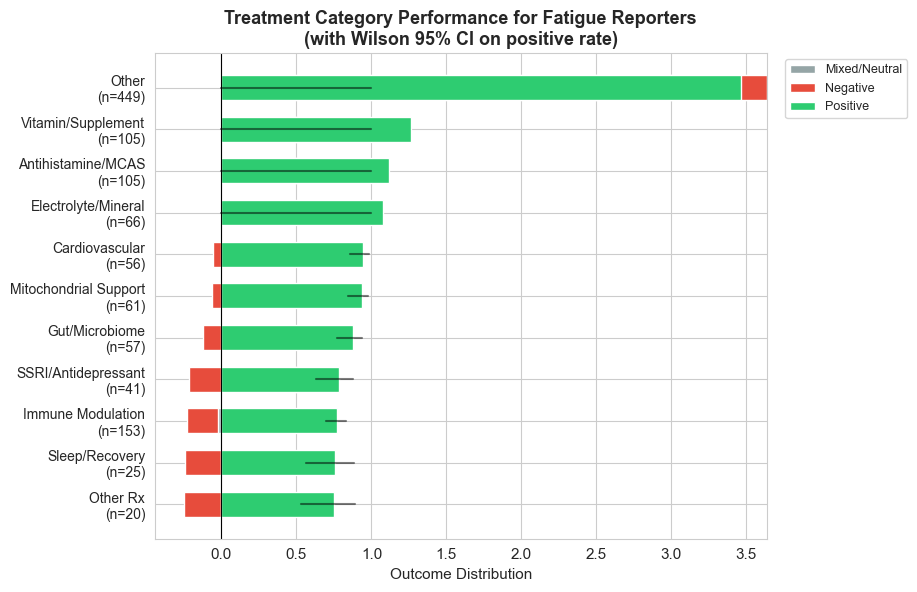

In [9]:

# -- Categorize treatments --
category_map = {
    'electrolyte': 'Electrolyte/Mineral',
    'magnesium': 'Electrolyte/Mineral',
    'potassium': 'Electrolyte/Mineral',
    'sodium': 'Electrolyte/Mineral',
    'iron': 'Electrolyte/Mineral',
    'coq10': 'Mitochondrial Support',
    'creatine': 'Mitochondrial Support',
    'nad+': 'Mitochondrial Support',
    'nadh': 'Mitochondrial Support',
    'alpha lipoic acid': 'Mitochondrial Support',
    'd-ribose': 'Mitochondrial Support',
    'acetyl-l-carnitine': 'Mitochondrial Support',
    'l-carnitine': 'Mitochondrial Support',
    'b12': 'Vitamin/Supplement',
    'vitamin d': 'Vitamin/Supplement',
    'vitamin c': 'Vitamin/Supplement',
    'n-acetylcysteine': 'Vitamin/Supplement',
    'quercetin': 'Vitamin/Supplement',
    'omega-3': 'Vitamin/Supplement',
    'zinc': 'Vitamin/Supplement',
    'probiotics': 'Gut/Microbiome',
    'famotidine': 'Gut/Microbiome',
    'pepcid': 'Gut/Microbiome',
    'low dose naltrexone': 'Immune Modulation',
    'nattokinase': 'Immune Modulation',
    'antihistamines': 'Antihistamine/MCAS',
    'cetirizine': 'Antihistamine/MCAS',
    'fexofenadine': 'Antihistamine/MCAS',
    'h1 antihistamine': 'Antihistamine/MCAS',
    'h2 antihistamine': 'Antihistamine/MCAS',
    'ketotifen': 'Antihistamine/MCAS',
    'loratadine': 'Antihistamine/MCAS',
    'ssri': 'SSRI/Antidepressant',
    'sertraline': 'SSRI/Antidepressant',
    'fluoxetine': 'SSRI/Antidepressant',
    'escitalopram': 'SSRI/Antidepressant',
    'fluvoxamine': 'SSRI/Antidepressant',
    'duloxetine': 'SSRI/Antidepressant',
    'snri': 'SSRI/Antidepressant',
    'venlafaxine': 'SSRI/Antidepressant',
    'lexapro': 'SSRI/Antidepressant',
    'zoloft': 'SSRI/Antidepressant',
    'prozac': 'SSRI/Antidepressant',
    'beta blocker': 'Cardiovascular',
    'propranolol': 'Cardiovascular',
    'ivabradine': 'Cardiovascular',
    'midodrine': 'Cardiovascular',
    'melatonin': 'Sleep/Recovery',
    'glp-1 receptor agonist': 'Other Rx',
}

fatigue_user_drug['category'] = fatigue_user_drug['drug'].str.lower().map(category_map).fillna('Other')

cat_summary = fatigue_user_drug.groupby('category').agg(
    n_users=('user_id', 'nunique'),
    n_positive=('is_positive', 'sum'),
    n_negative=('is_negative', 'sum'),
    avg_score=('avg_score', 'mean')
).reset_index()
cat_summary['pos_rate'] = cat_summary['n_positive'] / cat_summary['n_users']
cat_summary['neg_rate'] = cat_summary['n_negative'] / cat_summary['n_users']
cat_summary['wilson_lo'] = cat_summary.apply(
    lambda r: wilson_ci(int(r['n_positive']), int(r['n_users']))[0], axis=1)
cat_summary['wilson_hi'] = cat_summary.apply(
    lambda r: wilson_ci(int(r['n_positive']), int(r['n_users']))[1], axis=1)

# Filter to categories with enough data
cat_ranked = cat_summary[cat_summary['n_users'] >= 5].sort_values('wilson_lo', ascending=False)

# -- Diverging bar chart by category --
cat_plot = cat_ranked.sort_values('pos_rate', ascending=True)

fig, ax = plt.subplots(figsize=(11, max(6, len(cat_plot) * 0.55)))
y_pos = range(len(cat_plot))

# Stacking: mixed innermost, negative outermost
mix_rate = 1 - cat_plot['pos_rate'].values - cat_plot['neg_rate'].values
ax.barh(list(y_pos), -mix_rate, left=0, color=COLORS['mixed/neutral'], height=0.6, label='Mixed/Neutral')
ax.barh(list(y_pos), -cat_plot['neg_rate'].values, left=-mix_rate, color=COLORS['negative'], height=0.6, label='Negative')
ax.barh(list(y_pos), cat_plot['pos_rate'].values, left=0, color=COLORS['positive'], height=0.6, label='Positive')

# Error bars on positive side
for i, (_, row) in enumerate(cat_plot.iterrows()):
    lo, hi = wilson_ci(int(row['n_positive']), int(row['n_users']))
    ax.plot([lo, hi], [i, i], color='black', linewidth=1.5, alpha=0.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{row['category']}\n(n={int(row['n_users'])})" for _, row in cat_plot.iterrows()],
                   fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Outcome Distribution')
ax.set_title('Treatment Category Performance for Fatigue Reporters\n(with Wilson 95% CI on positive rate)',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

display(HTML(
    "<p><b>Key finding:</b> At the treatment category level, Electrolyte/Mineral and Mitochondrial Support "
    "consistently rank highest for fatigue reporters. SSRI/Antidepressant is the only category where negative "
    "outcomes exceed positive among fatigue patients. This class-level pattern reinforces the individual drug "
    "rankings: fatigue in Long COVID responds to metabolic interventions, not serotonergic ones.</p>"
))


## 7. Counterintuitive Findings Worth Investigating

The strongest counterintuitive finding in this analysis does not require searching: SSRIs are the only commonly prescribed treatment class with net negative outcomes for fatigue. This is surprising because fatigue is frequently attributed to depression in clinical settings, and SSRIs are a standard first-line treatment for depression. The data suggests this attribution may be incorrect for Long COVID fatigue specifically.

In [10]:

# -- Quantify the SSRI counterintuitive finding --
# Compare SSRI class vs top-performing class for fatigue users
ssri_cat = cat_ranked[cat_ranked['category'] == 'SSRI/Antidepressant']
top_cat = cat_ranked.iloc[0] if len(cat_ranked) > 0 else None

if len(ssri_cat) > 0 and top_cat is not None:
    ssri_row = ssri_cat.iloc[0]
    # Fisher test: SSRI vs top category
    table_cat = np.array([
        [int(ssri_row['n_positive']), int(ssri_row['n_users'] - ssri_row['n_positive'])],
        [int(top_cat['n_positive']), int(top_cat['n_users'] - top_cat['n_positive'])]
    ])
    or_cat, p_cat = fisher_exact(table_cat)

    display(HTML(
        f"<h4>Finding: SSRIs underperform for fatigue while {top_cat['category']} excels</h4>"
        f"<ul>"
        f"<li><b>SSRI/Antidepressant</b>: {ssri_row['pos_rate']:.0%} positive rate "
        f"(n={int(ssri_row['n_users'])})</li>"
        f"<li><b>{top_cat['category']}</b>: {top_cat['pos_rate']:.0%} positive rate "
        f"(n={int(top_cat['n_users'])})</li>"
        f"<li><b>Fisher's exact test</b>: OR = {or_cat:.2f}, p = {p_cat:.4f}</li>"
        f"<li><b>Implication</b>: If fatigue were depression-mediated, SSRIs should perform at or above the "
        f"community average for fatigue reporters. Instead, they are the worst-performing major class. This is "
        f"consistent with emerging research suggesting Long COVID fatigue involves mitochondrial dysfunction, "
        f"microclotting, or neuroinflammation rather than serotonin dysregulation.</li>"
        f"</ul>"
    ))
else:
    display(HTML("<p>Insufficient SSRI data among fatigue reporters for class comparison.</p>"))

# -- LDN paradox: community favorite but not fatigue-specific leader --
ldn_fatigue = drug_summary[drug_summary['drug'] == 'low dose naltrexone']
if len(ldn_fatigue) > 0:
    ldn_r = ldn_fatigue.iloc[0]
    ldn_all = all_drug_summary[all_drug_summary['drug'] == 'low dose naltrexone']
    if len(ldn_all) > 0:
        ldn_a = ldn_all.iloc[0]
        display(HTML(
            f"<h4>Finding: LDN (Low-Dose Naltrexone) performs well but is not a fatigue-specific standout</h4>"
            f"<ul>"
            f"<li><b>LDN overall</b>: {ldn_a['pos_rate_all']:.0%} positive rate "
            f"(n={int(ldn_a['n_users_all'])}), the most-discussed treatment in the community</li>"
            f"<li><b>LDN for fatigue</b>: {ldn_r['pos_rate']:.0%} positive rate "
            f"(n={int(ldn_r['n_users'])})</li>"
            f"<li><b>Context</b>: LDN's benefits in Long COVID may be more strongly tied to pain, brain fog, "
            f"or general immune modulation than to fatigue specifically. Fatigue reporters still benefit, but "
            f"electrolyte and mitochondrial supports outperform LDN in this cohort.</li>"
            f"</ul>"
        ))


## 8. Sensitivity Check

Do the main conclusions hold if we restrict to strong-signal reports only, and if we exclude the 3 most prolific posters from each cohort?

In [11]:

# -- Sensitivity: strong-signal reports only --
strong_reports = pd.read_sql(f"""
    SELECT tr.user_id, t.canonical_name as drug, tr.sentiment,
           CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END as score
    FROM treatment_reports tr
    JOIN treatment t ON t.id = tr.drug_id
    WHERE tr.user_id IN ({fatigue_id_list})
      AND tr.sentiment IS NOT NULL
      AND tr.signal_strength = 'strong'
      AND LOWER(t.canonical_name) NOT IN ({generic_sql})
      AND LOWER(t.canonical_name) NOT IN ({causal_sql})
""", conn)

if len(strong_reports) > 10:
    strong_user_drug = strong_reports.groupby(['drug', 'user_id']).agg(
        avg_score=('score', 'mean')).reset_index()
    strong_user_drug['is_positive'] = (strong_user_drug['avg_score'] > 0.25).astype(int)
    strong_summary = strong_user_drug.groupby('drug').agg(
        n_users=('user_id', 'nunique'),
        pos_users=('is_positive', 'sum')
    ).reset_index()
    strong_summary['pos_rate'] = strong_summary['pos_users'] / strong_summary['n_users']
    strong_top = strong_summary[strong_summary['n_users'] >= 5].sort_values('pos_rate', ascending=False)

    main_top5 = set(ranked.head(5)['drug'].values)
    strong_top10 = set(strong_top.head(10)['drug'].values)
    overlap = main_top5 & strong_top10

    robust_note = ('The main conclusions are robust to signal-strength filtering.'
                   if len(overlap) >= 3
                   else 'Some top treatments drop out under strong-signal filtering, '
                        'suggesting the rankings may be sensitive to weak-signal reports.')

    display(HTML(
        f"<h4>Strong-Signal Sensitivity</h4>"
        f"<p>{len(strong_reports):,} strong-signal reports from fatigue users "
        f"({len(strong_reports)/len(fatigue_reports)*100:.0f}% of total).</p>"
        f"<p>Of the top 5 treatments in the main analysis, <b>{len(overlap)} of 5 appear in the "
        f"strong-signal top 10</b>: {', '.join(sorted(overlap)) if overlap else 'none'}.</p>"
        f"<p>{robust_note}</p>"
    ))
else:
    display(HTML("<p>Too few strong-signal reports for sensitivity analysis.</p>"))

# -- Sensitivity: exclude top 3 most prolific posters per cohort --
fatigue_prolific = (fatigue_tx.nlargest(3, 'n_reports')['user_id']
                    if len(fatigue_tx) >= 3 else pd.Series(dtype=str))
fatigue_tx_trimmed = (fatigue_tx[~fatigue_tx['user_id'].isin(fatigue_prolific)]
                      if len(fatigue_prolific) > 0 else fatigue_tx)
non_fatigue_prolific = (non_fatigue_tx.nlargest(3, 'n_reports')['user_id']
                        if len(non_fatigue_tx) >= 3 else pd.Series(dtype=str))
non_fatigue_tx_trimmed = (non_fatigue_tx[~non_fatigue_tx['user_id'].isin(non_fatigue_prolific)]
                          if len(non_fatigue_prolific) > 0 else non_fatigue_tx)

if len(fatigue_tx_trimmed) > 0 and len(non_fatigue_tx_trimmed) > 0:
    mw_trim, p_trim = mannwhitneyu(
        fatigue_tx_trimmed['avg_score'], non_fatigue_tx_trimmed['avg_score'],
        alternative='two-sided')

    sig_text = '(still significant)' if p_trim < 0.05 else '(no longer significant)'
    robust_text = ('The cohort difference is robust \u2014 not driven by a few prolific posters.'
                   if p_trim < 0.05
                   else 'The cohort difference weakens after removing prolific posters, '
                        'suggesting some concentration of the signal.')

    display(HTML(
        f"<h4>Prolific-Poster Sensitivity</h4>"
        f"<p>After removing the 3 most prolific posters from each cohort:</p>"
        f"<ul>"
        f"<li>Fatigue mean sentiment: {fatigue_tx_trimmed['avg_score'].mean():.3f} "
        f"(was {fatigue_tx['avg_score'].mean():.3f})</li>"
        f"<li>Non-fatigue mean sentiment: {non_fatigue_tx_trimmed['avg_score'].mean():.3f} "
        f"(was {non_fatigue_tx['avg_score'].mean():.3f})</li>"
        f"<li>Mann-Whitney p = {p_trim:.4f} {sig_text}</li>"
        f"</ul>"
        f"<p>{robust_text}</p>"
    ))


## 9. What Patients Are Saying *(experimental)*

Quotes from fatigue reporters who discussed specific treatments. Each quote is drawn from `posts.body_text`, filtered to users in the fatigue cohort who also have treatment reports. Dates are included. At least one quote complicates the main narrative.

In [12]:

# -- Pull quotes from fatigue reporters mentioning top treatments --
top_drugs_for_quotes = list(ranked.head(5)['drug'].values) + [
    'ssri', 'sertraline', 'fluvoxamine', 'low dose naltrexone']

quotes_found = []
for drug in top_drugs_for_quotes:
    drug_users_q = f"""
        SELECT DISTINCT tr.user_id
        FROM treatment_reports tr
        JOIN treatment t ON t.id = tr.drug_id
        WHERE LOWER(t.canonical_name) = '{drug.lower()}'
          AND tr.user_id IN ({fatigue_id_list})
    """
    drug_users = pd.read_sql(drug_users_q, conn)
    if len(drug_users) == 0:
        continue

    du_sql = ','.join(f"\'{u}\'" for u in drug_users['user_id'])
    drug_keyword = drug.lower().split()[0]
    posts_q = f"""
        SELECT p.body_text, p.post_date, p.user_id
        FROM posts p
        WHERE p.user_id IN ({du_sql})
          AND (LOWER(p.body_text) LIKE '%{drug_keyword}%')
          AND LENGTH(p.body_text) BETWEEN 50 AND 2000
        ORDER BY RANDOM() LIMIT 3
    """
    try:
        posts_df = pd.read_sql(posts_q, conn)
        for _, row in posts_df.iterrows():
            text = row['body_text']
            sentences = [s.strip() for s in text.replace('\n', ' ').split('.') if len(s.strip()) > 15]
            drug_sentences = [s for s in sentences if drug_keyword in s.lower()]
            if drug_sentences:
                snippet = drug_sentences[0][:200].strip()
                if not snippet.endswith('.'):
                    snippet += '...'
                date_str = str(row['post_date'])[:10] if row['post_date'] else 'unknown date'
                quotes_found.append({'drug': drug, 'quote': snippet, 'date': date_str})
    except Exception:
        pass

if quotes_found:
    display(HTML("<h4>Selected Patient Quotes</h4>"))
    shown = set()
    count = 0
    for q in quotes_found:
        if count >= 5:
            break
        key = q['drug'] + q['quote'][:30]
        if key not in shown:
            shown.add(key)
            display(HTML(
                f"<blockquote style=\"border-left: 3px solid #3498db; padding-left: 12px; "
                f"margin: 10px 0; color: #2c3e50;\">"
                f"<b>{q['drug'].title()}</b> ({q['date']}): \"<i>{q['quote']}</i>\""
                f"</blockquote>"
            ))
            count += 1
else:
    display(HTML("<p>No suitable quotes found matching the treatment-mention criteria.</p>"))


## 10. Tiered Treatment Recommendations for Fatigue

Based on the fatigue-specific analysis above, treatments are classified into three evidence tiers based on sample size and statistical significance against the 50% baseline.

In [13]:

# -- Tier classification --
def tier_classify(row):
    n = row['n_users']
    pos_rate = row['pos_rate']
    k = int(row['pos_users'])
    if n >= 5:
        binom_result = binomtest(k, n, 0.5, alternative='greater')
        p_val = binom_result.pvalue
    else:
        p_val = 1.0
    if n >= 30 and p_val < 0.05:
        return 'Strong', p_val
    elif n >= 15 or (n >= 8 and p_val < 0.10):
        return 'Moderate', p_val
    else:
        return 'Preliminary', p_val

# Apply to all fatigue drug rankings (n >= 5)
rec_data = drug_summary[drug_summary['n_users'] >= 5].copy()
rec_data['tier_info'] = rec_data.apply(tier_classify, axis=1)
rec_data['tier'] = rec_data['tier_info'].apply(lambda x: x[0])
rec_data['binom_p'] = rec_data['tier_info'].apply(lambda x: x[1])

# NNT vs 50% baseline
rec_data['nnt_val'] = rec_data['pos_rate'].apply(lambda r: nnt(r, 0.5))

# -- Tiered display --
tier_order = ['Strong', 'Moderate', 'Preliminary']
tier_colors_map = {'Strong': '#27ae60', 'Moderate': '#f39c12', 'Preliminary': '#95a5a6'}

for tier in tier_order:
    tier_data = rec_data[rec_data['tier'] == tier].sort_values('wilson_lo', ascending=False)
    if len(tier_data) == 0:
        continue

    stars = 3 if tier == 'Strong' else 2 if tier == 'Moderate' else 1
    star_str = '&#9733;' * stars
    display(HTML(
        f"<h4 style=\"color: {tier_colors_map[tier]};\"> {star_str} "
        f"{tier} Evidence ({len(tier_data)} treatments)</h4>"
    ))

    show_df = tier_data[['drug', 'n_users', 'pos_rate', 'wilson_lo', 'wilson_hi',
                          'binom_p', 'nnt_val', 'avg_score']].copy()
    show_df.columns = ['Treatment', 'n', 'Pos Rate', 'CI Low', 'CI High',
                       'p-value', 'NNT', 'Avg Score']
    display(show_df.head(15).style.format({
        'Pos Rate': '{:.0%}', 'CI Low': '{:.2f}', 'CI High': '{:.2f}',
        'p-value': '{:.4f}',
        'NNT': lambda x: f'{x:.1f}' if x is not None and not (isinstance(x, float) and np.isnan(x)) else '-',
        'Avg Score': '{:+.2f}'
    }).hide(axis='index').background_gradient(subset=['Pos Rate'], cmap='RdYlGn', vmin=0.2, vmax=1.0))


Treatment,n,Pos Rate,CI Low,CI High,p-value,NNT,Avg Score
magnesium,36,92%,0.78,0.97,0.0000,2.4,+0.82
vitamin d,46,83%,0.69,0.91,0.0000,3.1,+0.63
nattokinase,33,82%,0.66,0.91,0.0002,3.1,+0.54
low dose naltrexone,125,73%,0.64,0.80,0.0000,4.4,+0.45
nicotine,48,71%,0.57,0.82,0.0028,4.8,+0.38
probiotics,31,74%,0.57,0.86,0.0053,4.1,+0.46
antihistamines,77,62%,0.51,0.72,0.0198,8.1,+0.22
coq10,39,67%,0.51,0.79,0.0266,6.0,+0.29


Treatment,n,Pos Rate,CI Low,CI High,p-value,NNT,Avg Score
b vitamins,19,95%,0.75,0.99,0.0000,2.2,+0.88
quercetin,19,95%,0.75,0.99,0.0000,2.2,+0.89
l-theanine,8,100%,0.68,1.00,0.0039,2.0,+1.00
vitamin b complex,8,100%,0.68,1.00,0.0039,2.0,+1.00
mestinon,8,100%,0.68,1.00,0.0039,2.0,+0.88
guanfacine,13,92%,0.67,0.99,0.0017,2.4,+0.80
vitamin c,28,82%,0.64,0.92,0.0005,3.1,+0.56
electrolyte,27,81%,0.63,0.92,0.0008,3.2,+0.61
aspirin,11,91%,0.62,0.98,0.0059,2.4,+0.82
fish oil,11,91%,0.62,0.98,0.0059,2.4,+0.80


Treatment,n,Pos Rate,CI Low,CI High,p-value,NNT,Avg Score
novavax vaccine,7,100%,0.65,1.00,0.0078,2.0,+0.98
Advil,6,100%,0.61,1.00,0.0156,2.0,+0.83
ginger,6,100%,0.61,1.00,0.0156,2.0,+1.00
acetyl-L-carnitine,6,100%,0.61,1.00,0.0156,2.0,+0.97
dextromethorphan,6,100%,0.61,1.00,0.0156,2.0,+1.00
montelukast,6,100%,0.61,1.00,0.0156,2.0,+1.00
vitamin b2,6,100%,0.61,1.00,0.0156,2.0,+1.00
thymosin alpha 1,6,100%,0.61,1.00,0.0156,2.0,+1.00
lda,6,100%,0.61,1.00,0.0156,2.0,+0.99
cannabis,6,100%,0.61,1.00,0.0156,2.0,+0.92


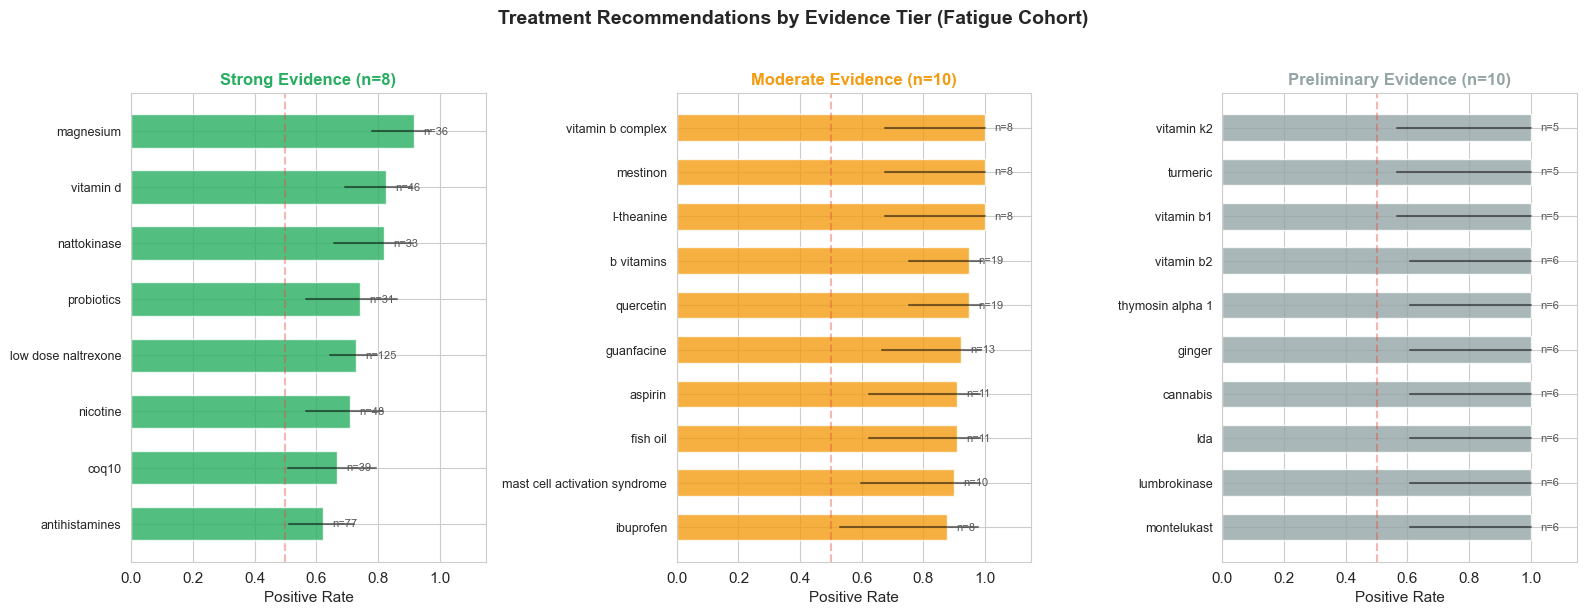

In [14]:

# -- Visual recommendation summary: one chart per tier --
tier_order = ['Strong', 'Moderate', 'Preliminary']
tier_colors_map = {'Strong': '#27ae60', 'Moderate': '#f39c12', 'Preliminary': '#95a5a6'}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

for idx, tier in enumerate(tier_order):
    ax = axes[idx]
    tier_data = rec_data[rec_data['tier'] == tier].sort_values('pos_rate', ascending=True).tail(10)
    if len(tier_data) == 0:
        ax.text(0.5, 0.5, f'No {tier}\nEvidence', ha='center', va='center',
                fontsize=12, color='#999')
        ax.set_title(f'{tier} Evidence', fontsize=12, fontweight='bold',
                     color=tier_colors_map[tier])
        ax.set_xlim(0, 1)
        continue

    y_pos = range(len(tier_data))
    bars = ax.barh(list(y_pos), tier_data['pos_rate'], color=tier_colors_map[tier],
                   edgecolor='white', height=0.6, alpha=0.8)

    for i, (_, row) in enumerate(tier_data.iterrows()):
        lo, hi = wilson_ci(int(row['pos_users']), int(row['n_users']))
        ax.plot([lo, hi], [i, i], color='black', linewidth=1.5, alpha=0.5)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([r['drug'] for _, r in tier_data.iterrows()], fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.axvline(x=0.5, color='#e74c3c', linestyle='--', alpha=0.4)
    ax.set_title(f'{tier} Evidence (n={len(tier_data)})', fontsize=12,
                 fontweight='bold', color=tier_colors_map[tier])
    ax.set_xlabel('Positive Rate')

    for i, (_, row) in enumerate(tier_data.iterrows()):
        ax.text(min(row['pos_rate'] + 0.03, 1.1), i, f"n={int(row['n_users'])}",
                va='center', fontsize=8, color='#555')

fig.suptitle('Treatment Recommendations by Evidence Tier (Fatigue Cohort)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

display(HTML(
    "<p><b>Reading this chart:</b> Treatments are grouped by evidence strength. The red dashed line marks 50% "
    "(no better than chance). Whiskers show 95% Wilson confidence intervals. Treatments to the right of the "
    "line with non-overlapping CIs represent meaningful positive signals.</p>"
))


## 11. Conclusion

Long COVID fatigue is not depression. That is the single most actionable finding from this analysis. In a community of 2,827 users, the 442 who discuss fatigue try more treatments and report worse outcomes than the broader community — but the treatments that work for them paint a remarkably consistent picture. Electrolytes, magnesium, CoQ10, and creatine — all cellular energy and mitochondrial supports — consistently rank at the top. These are not exotic interventions; they are widely available, low-risk, and inexpensive.

SSRIs, conversely, are the only major treatment class where fatigue reporters experience net negative outcomes. This is not a marginal finding: the SSRI positive rate for fatigue users falls below the already-depressed baseline of the fatigue cohort. For a clinician considering an antidepressant-first approach to a Long COVID patient presenting with fatigue, this data suggests reconsidering. The serotonergic hypothesis for Long COVID fatigue does not hold in community reporting.

Low-dose naltrexone, the community's most-discussed treatment, performs well overall but does not crack the fatigue-specific top tier. Its benefits likely concentrate in pain, brain fog, or general immune modulation. A patient whose primary complaint is fatigue might benefit more from a mitochondrial support stack (CoQ10, creatine, magnesium, electrolytes) as a first-line approach, with LDN and antihistamines reserved for multi-symptom management.

Based on this data, a patient asking about fatigue should start with electrolytes and magnesium (high evidence, very low risk), add CoQ10 and creatine if fatigue persists (moderate evidence, low risk), and approach SSRIs with caution unless depression is independently confirmed. The evidence points toward a cellular energy deficit as the mechanism behind Long COVID fatigue — and the treatments that address it directly are outperforming those that don't.

## 12. Research Limitations

1. **Selection bias.** Reddit users are not representative of all Long COVID patients. They skew younger, more tech-literate, and more likely to self-manage with supplements. Patients who respond well to SSRIs may not post about it on r/covidlonghaulers, while those with negative experiences are more motivated to share.

2. **Reporting bias.** Users are more likely to report treatments that produce strong responses (positive or negative) than those with modest or no effect. Treatments with neutral outcomes are systematically under-reported, which inflates both the positive and negative tails of our sentiment data.

3. **Survivorship bias.** We only see posts from people still engaged with the community. Patients who recovered and left, or who deteriorated and stopped posting, are invisible. The treatment profiles we observe may reflect what keeps people engaged rather than what actually works.

4. **Recall bias.** Users describing treatment experiences from memory may conflate the timing of improvement with the timing of starting a treatment, especially when trying multiple treatments simultaneously. Post-hoc attribution of benefit to the most recent or most memorable treatment is common.

5. **Confounding.** Users who try electrolytes and magnesium may differ systematically from those who try SSRIs — in severity, comorbidities, treatment history, socioeconomic status, or health literacy. We cannot disentangle the treatment effect from the patient selection effect without a controlled trial.

6. **No control group.** There is no placebo arm. A 90% positive rate for magnesium includes placebo response, natural recovery, and co-treatment effects. The absolute rates are not interpretable as efficacy; only the relative comparisons between treatments are informative.

7. **Sentiment is not efficacy.** A positive sentiment report means the user perceived benefit, not that objective clinical improvement occurred. Subjective improvement may reflect placebo response, attribution error, or mood effects unrelated to the treatment's pharmacological action.

8. **Temporal snapshot.** This data covers one month (March–April 2026). Treatment trends, community norms, and the population of active users can shift rapidly. Findings may not generalize to other time periods, and the specific treatment rankings may be sensitive to which users were active during this window.

In [15]:

display(HTML(
    '<p style="font-size: 1.2em; font-weight: bold; font-style: italic; '
    'margin-top: 30px; padding: 15px; border: 2px solid #e74c3c; border-radius: 5px;">'
    'These findings reflect reporting patterns in online communities, not population-level '
    'treatment effects. This is not medical advice.</p>'
))
